# Project 1 Dashbord Basics
The following Jupyter Notebook contains the data handelig of the file "reservoirs.csv". Where the data set was explored, altered and plotted. Below is also a word log describing the work process, and a short description of AI usage. 

### Word log
This compulsory assignment began with attemting to achieve an overwiev of the task at hand. An account on github was created and the nesseccary libraries imported. 

Then the data set was explored, with the first 10 rows shown. This revealed the columns were in norwegian, which were translated into english, and that the rows were not in cronological order according to the timestamp. This was handled by ensuring the date column was read as datetime and further sorted after this column. 

During the initial exploration part the plots were really messy. This lead to more rescherch into the columns "area_type", "area_number", "iso_year" and "iso_week". Where it as discovered that the reason for messy plots were that several areas of norway was plotted at the same time. For simplicity the aggregated values across Norway marked with "NO" and "0" was the only walues used in the plotting. 

The second part of the assignment, creating the streamlit app, was first done with very simple code just to get a visual on how streamlit worked. After having created all the files nesseccary, and viewing the app, the remaining requirements were implemented by some back and fourth work. Furthermore, as the project calls for four pages in the sidebar menu but only three were provided a dummy "about" page was created. 

I also created a public GitHub repository and uploaded the Jupyter Notebook, Streamlit files, CSV file and txt file. The repository was then connected to Streamlit so the application could run online. 

During this assignment I have learned how to deploy an app by using python. Moreover, github have become a lot more clearer on its usage, making it a tool which I now can use for later coursework and in other subjects. It will be interesting to see how this app will evolve with the later assignments. 

### AI usage
In the beginning of the process both github and streamlit seemed daunting. Here AI was used to further understand what these pages could be used for as well as provide a good overall view of the project at hand. AI has also been used to find relevant commands and for further understanding. A prompt example being "What is the command in pandas for reading files such as reserviors.csv", here "pd.read_csv()" was provided from AI and further applied in the jupyter notebook. When first creating the streamlit app AI was used to find correct functions to best solve the task. 

### Reading, understanding and shaping the data

In [81]:
# Imports
import streamlit as st 
import pandas as pd 
import matplotlib.pyplot as plt 

In [82]:
# Reading data
df = pd.read_csv("reservoirs.csv")

# Displaying the first 10 rows to find the different column names
df.head(10)


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301
5,2017-11-05,EL,4,2017,44,0.794520,21.079208,16.747847,0001-01-01T00:00:00,0.804085,-0.009565
6,2003-03-02,EL,1,2003,9,0.195046,6.003264,1.170914,0001-01-01T00:00:00,0.222014,-0.026968
7,2000-11-26,EL,4,2000,47,0.866371,21.079208,18.262426,0001-01-01T00:00:00,0.884963,-0.018591
8,2016-09-04,EL,1,2016,35,0.890967,6.003264,5.348708,0001-01-01T00:00:00,0.881946,0.009021
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23T13:00:00,0.776765,0.060084


In [83]:
# Renaming colums 
df = df.rename(columns={
    "dato_Id": "date_id",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "stored_energy_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_level_previous_week",
    "endring_fyllingsgrad": "change_in_fill_level"
})

In [84]:
# Printing column information
print("number of rows", df.shape[0])
print("number of columns", df.shape[1])

number of rows 14877
number of columns 11


In [85]:
# Trying to further undertand our dataset
df.groupby(
    ["area_type", "area_number"]
).size()

area_type  area_number
EL         1              1653
           2              1653
           3              1653
           4              1653
           5              1653
NO         0              1653
VASS       1              1653
           2              1653
           3              1653
dtype: int64

In [86]:
# Ensuring the date_id is read as datetime
df["date_id"] = pd.to_datetime(df["date_id"])

# Sort observations by date
df = df.sort_values("date_id")


Noticing that the dataset contains data from several areas. Choosing to further plot only the NO marked rows as this seems to be the national aggregate. 

### Plotting each column seperately

In [87]:
# Choosing the relevant columns to plot
# (not the first five as they are just identifiers and not next_publication_date)
columns = [
    "fill_level",
    "capacity_TWh",
    "stored_energy_TWh",
    "fill_level_previous_week",
    "change_in_fill_level"
]

In [88]:
# Making a dataframe for only the aggregated values
df_no = df[
    (df["area_type"] == "NO") &
    (df["area_number"] == 0)
].copy()

In [89]:
# Making a plotting function
def plot_columns_seperately(column):
    plt.figure(figsize=(12, 5))
    plt.plot(df_no["date_id"], df_no[column])
    plt.title(f"{column} - National aggregate")
    plt.xlabel("Year")
    plt.ylabel(column)
    plt.grid()
    plt.show()

c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be r

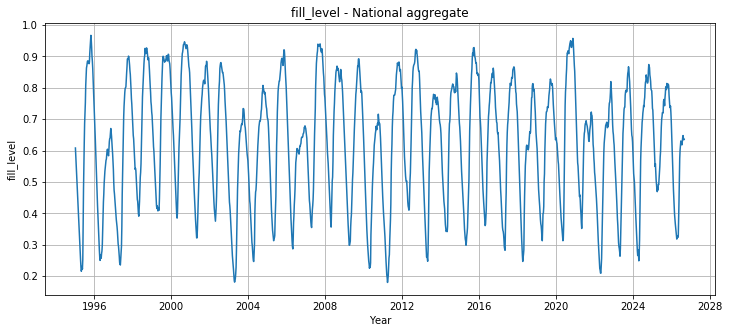

c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


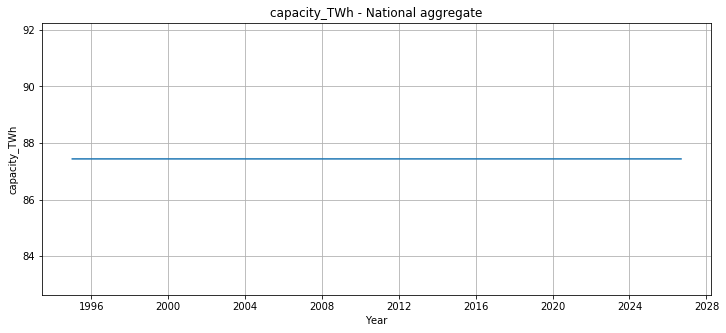

c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


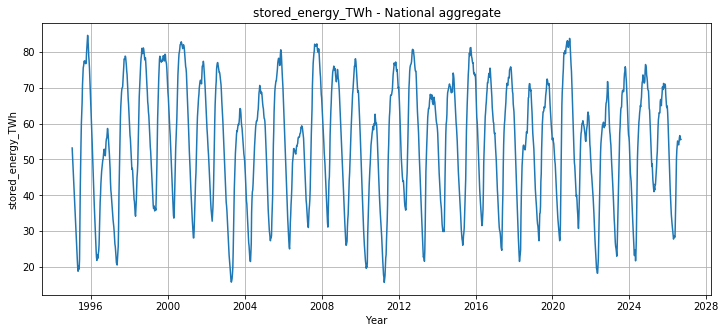

c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


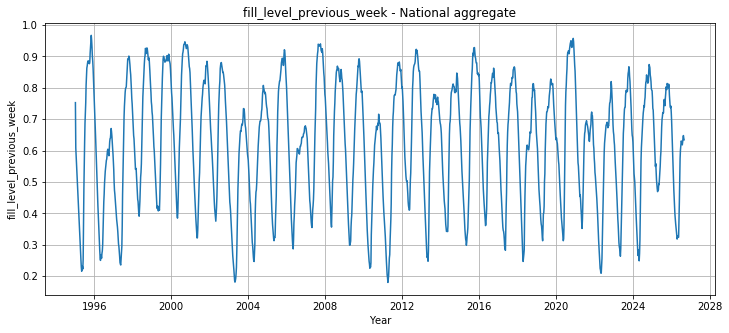

c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


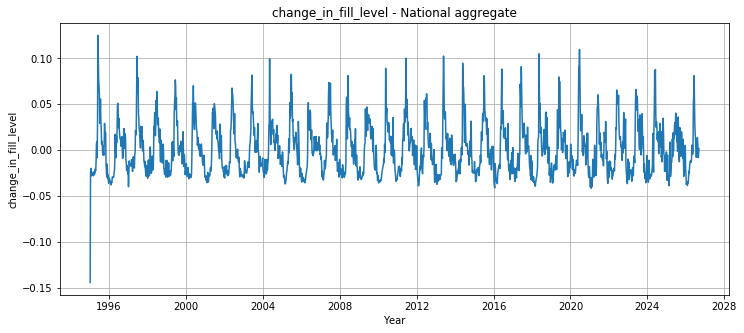

In [90]:
# Plotting all the relevant columns 
for column in columns:
    plot_columns_seperately(column)

### Plotting all the columns together

c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\axes\_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]
c:\Users\irene\Anaconda3\lib\site-packages\matplotlib\cbook\__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and

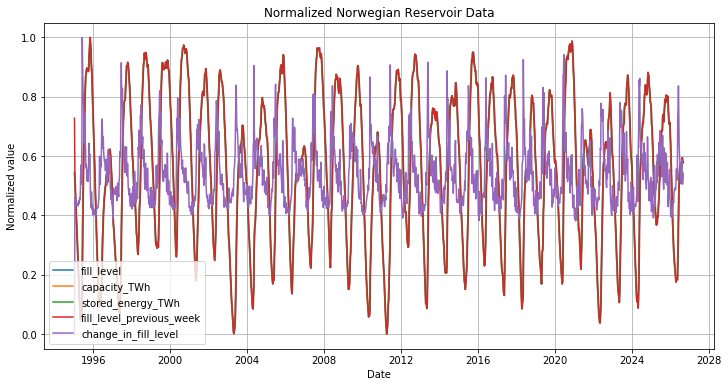

In [91]:
# Normalize each column to a scale between 0 and 1
normalized_df = df_no[columns].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# Plot all normalized columns together
plt.figure(figsize=(12, 6))

for column in columns:
    plt.plot(df_no["date_id"], normalized_df[column], label=column)

plt.title("Normalized Norwegian Reservoir Data")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend()
plt.grid()
plt.show()